# Appendix Cancer Prediction — Full Project Notebook
### NYU CSGY-6513 | Big Data



**Dataset:** `appendix_cancer_prediction_dataset.csv` — 260,000 patients · 25 features  
**Target:** `Appendix_Cancer_Prediction` (Yes = Cancer / No = No Cancer)

---
This notebook is structured in **three parts**:
1. **Part 1 — EDA & Visualization** 
2. **Part 2 — PySpark ML Training Pipeline**
3. **Part 3 — Streamlit App Demo**

---
# PART 1 — Exploratory Data Analysis & Visualization
**Author: Jyotsana Sharma**

## 1.1 Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pointbiserialr
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold', 'figure.facecolor': 'white'})
C_YES = '#e05c5c'
C_NO  = '#5c9ae0'
CANCER_PAL = {'Yes': C_YES, 'No': C_NO}
print('EDA libraries loaded.')

EDA libraries loaded.


## 1.2 Load & Inspect Data

In [2]:
df = pd.read_csv('appendix_cancer_prediction_dataset.csv')
print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
df.head(3)

Shape  : 260,000 rows x 25 columns
Memory : 241.4 MB


,Patient_ID,Country,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,...,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Diagnosis_Delay_Days,Treatment_Type,Survival_Years_After_Diagnosis,Appendix_Cancer_Prediction
0,PID_000001,China,67,Female,28.6,No,Low,Yes,No,Diabetes,...,228,8.1,4.4,361,Negative,Mild,691,Surgery,6.5,Yes
1,PID_000002,Saudi Arabia,83,Female,19.4,No,Low,No,No,Diabetes,...,186,9.7,6.2,235,Negative,Moderate,275,Chemotherapy,1.6,No
2,PID_000003,France,52,Female,17.2,No,Low,Yes,No,Diabetes,...,231,8.2,4.6,269,Negative,Moderate,668,Chemotherapy,0.7,No


In [3]:
df.describe(include='all').T[['count','unique','top','mean','std','min','max']].fillna('-')

,count,unique,top,mean,std,min,max
Patient_ID,260000.0,260000,PID_000001,-,-,-,-
Country,260000.0,25,USA,-,-,-,-
Age,260000.0,-,-,53.443331,20.750951,18.0,89.0
Gender,260000.0,3,Female,-,-,-,-
BMI,260000.0,-,-,24.996457,4.997116,1.1,48.1
Smoking_Status,260000.0,2,No,-,-,-,-
Alcohol_Consumption,260000.0,3,Low,-,-,-,-
Family_History_Cancer,260000.0,2,No,-,-,-,-
Genetic_Mutations,260000.0,2,No,-,-,-,-
Chronic_Diseases,129913.0,2,Hypertension,-,-,-,-


## 1.3 Missing Value Analysis & Imputation

In [4]:
total = len(df)
missing = df.isnull().sum()
missing = missing[missing > 0]
print('=== MISSING VALUES ===')
for col, cnt in missing.items():
    print(f'  {col:<28}  {cnt:>7,}  ({cnt/total*100:.1f}%)')

print()
print('Chronic_Diseases existing values:', df['Chronic_Diseases'].value_counts().to_dict())
print('Treatment_Type existing values  :', df['Treatment_Type'].value_counts().to_dict())

=== MISSING VALUES ===
  Chronic_Diseases              130,087  (50.0%)
  Treatment_Type                 26,074  (10.0%)

Chronic_Diseases existing values: {'Hypertension': 77831, 'Diabetes': 52082}
Treatment_Type existing values  : {'Surgery': 103398, 'Chemotherapy': 78269, 'Radiation': 52259}


In [5]:
# Check if missingness is informative (does it correlate with the target?)
for col in ['Chronic_Diseases', 'Treatment_Type']:
    df['_miss'] = df[col].isnull()
    rate = df.groupby('_miss')['Appendix_Cancer_Prediction'].apply(lambda x: (x=='Yes').mean()*100).round(2)
    print(f'{col}:  Present={rate[False]:.2f}%  Missing={rate[True]:.2f}%  diff={abs(rate[True]-rate[False]):.2f}pp')
df.drop(columns=['_miss'], inplace=True)

# Structural imputation:
# NaN in Chronic_Diseases = no chronic condition
# NaN in Treatment_Type   = no treatment received
df['Chronic_Diseases'] = df['Chronic_Diseases'].fillna('None')
df['Treatment_Type']   = df['Treatment_Type'].fillna('None / Untreated')
print(f'\nNulls remaining: {df.isnull().sum().sum()}')

Chronic_Diseases:  Present=15.12%  Missing=15.10%  diff=0.02pp
Treatment_Type:  Present=15.07%  Missing=15.50%  diff=0.43pp

Nulls remaining: 0


## 1.4 Feature Engineering

In [6]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,20,35,50,65,80,120],
                         labels=['<20','20-35','36-50','51-65','66-80','80+'])
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,35,100],
                             labels=['Underweight','Normal','Overweight','Obese I','Obese II+'])
df['Cancer'] = (df['Appendix_Cancer_Prediction'] == 'Yes').astype(int)

cat_cols = ['Gender','Smoking_Status','Alcohol_Consumption','Family_History_Cancer',
            'Genetic_Mutations','Chronic_Diseases','Physical_Activity_Level','Diet_Type',
            'Radiation_Exposure','Previous_Cancers','Tumor_Markers','Symptom_Severity','Treatment_Type']
df_enc = df.copy()
for c in cat_cols:
    df_enc[c] = df_enc[c].astype('category').cat.codes

cancer_yes = df[df['Cancer']==1]
cancer_no  = df[df['Cancer']==0]
print('Feature engineering complete.')
print(f'Cancer-positive: {len(cancer_yes):,}  |  Cancer-negative: {len(cancer_no):,}')

Feature engineering complete.
Cancer-positive: 39,287  |  Cancer-negative: 220,713


## Figure 1 — Target Class Distribution
> **Key finding:** 85%/15% class imbalance — drove class weighting in all ML models.

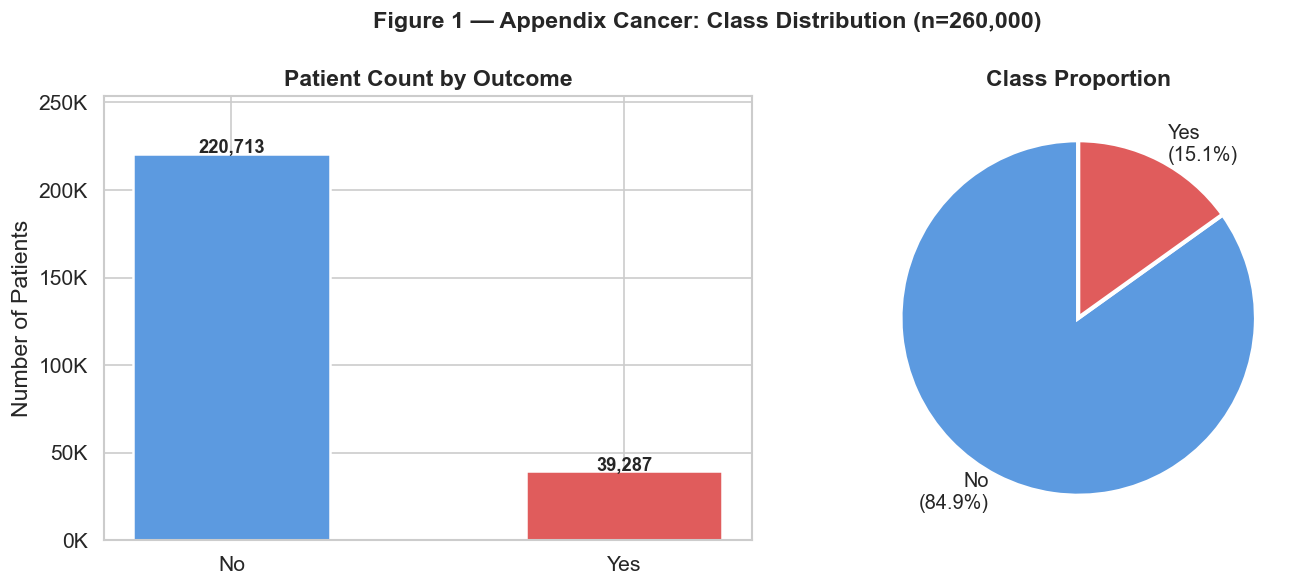

In [7]:
counts = df['Appendix_Cancer_Prediction'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1 — Appendix Cancer: Class Distribution (n=260,000)', fontsize=14, fontweight='bold')

colors = [CANCER_PAL[l] for l in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Patient Count by Outcome')
axes[0].set_ylabel('Number of Patients')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{bar.get_height():,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, counts.max()*1.15)

axes[1].pie(counts.values,
            labels=[f'{l}\n({v/len(df)*100:.1f}%)' for l,v in zip(counts.index, counts.values)],
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2.5},
            textprops={'fontsize':12})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('viz1_target_distribution.png', bbox_inches='tight', dpi=130)
plt.show()

## Figure 2 — Age & Gender Distributions
> **Key finding:** Age carries no signal (p=0.35). Gender is the only statistically significant feature (p=0.014).

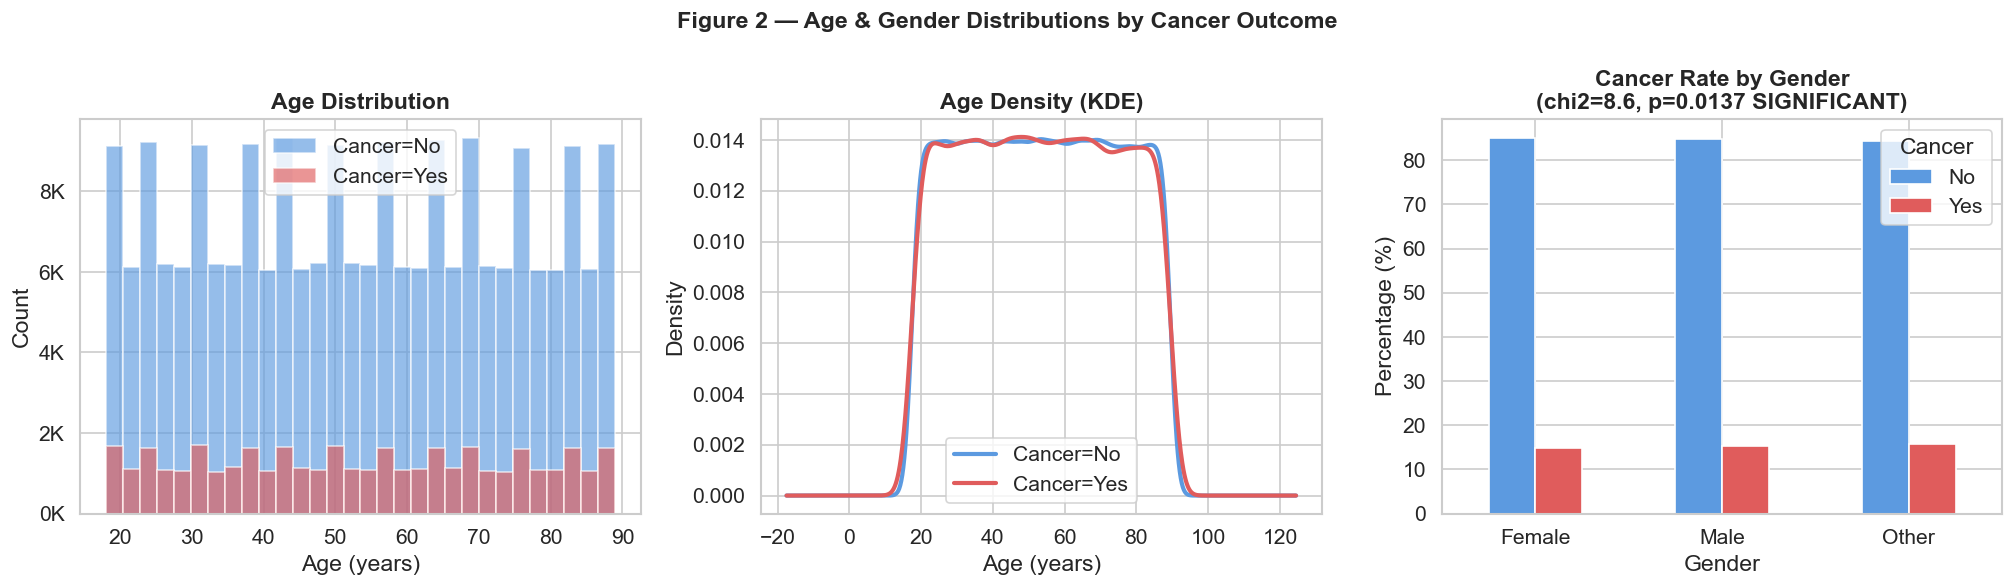

Age median — Cancer: 53 | No Cancer: 53
Gender chi2=8.58, p=0.0137


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 2 — Age & Gender Distributions by Cancer Outcome', fontsize=14, fontweight='bold')

for label, grp in df.groupby('Appendix_Cancer_Prediction'):
    axes[0].hist(grp['Age'], bins=30, alpha=0.65, color=CANCER_PAL[label],
                 label=f'Cancer={label}', edgecolor='white')
axes[0].set_title('Age Distribution'); axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

for label, grp in df.groupby('Appendix_Cancer_Prediction'):
    grp['Age'].plot.kde(ax=axes[1], color=CANCER_PAL[label], linewidth=2.5, label=f'Cancer={label}')
axes[1].set_title('Age Density (KDE)'); axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density'); axes[1].legend()

ct_g = pd.crosstab(df['Gender'], df['Appendix_Cancer_Prediction'])
chi2_g, p_g, _, _ = chi2_contingency(ct_g)
gender_pct = ct_g.div(ct_g.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[2], color=[C_NO, C_YES], edgecolor='white', rot=0)
axes[2].set_title(f'Cancer Rate by Gender\n(chi2={chi2_g:.1f}, p={p_g:.4f} SIGNIFICANT)')
axes[2].set_ylabel('Percentage (%)'); axes[2].legend(title='Cancer', labels=['No','Yes'])

plt.tight_layout()
plt.savefig('viz2_age_gender.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'Age median — Cancer: {cancer_yes["Age"].median():.0f} | No Cancer: {cancer_no["Age"].median():.0f}')
print(f'Gender chi2={chi2_g:.2f}, p={p_g:.4f}')

## Figure 3 — Risk Factor Cancer Rates
> **Key finding:** Smoking, alcohol, family history, genetics — all flat at ~15%. No risk factor discriminates cancer from non-cancer.

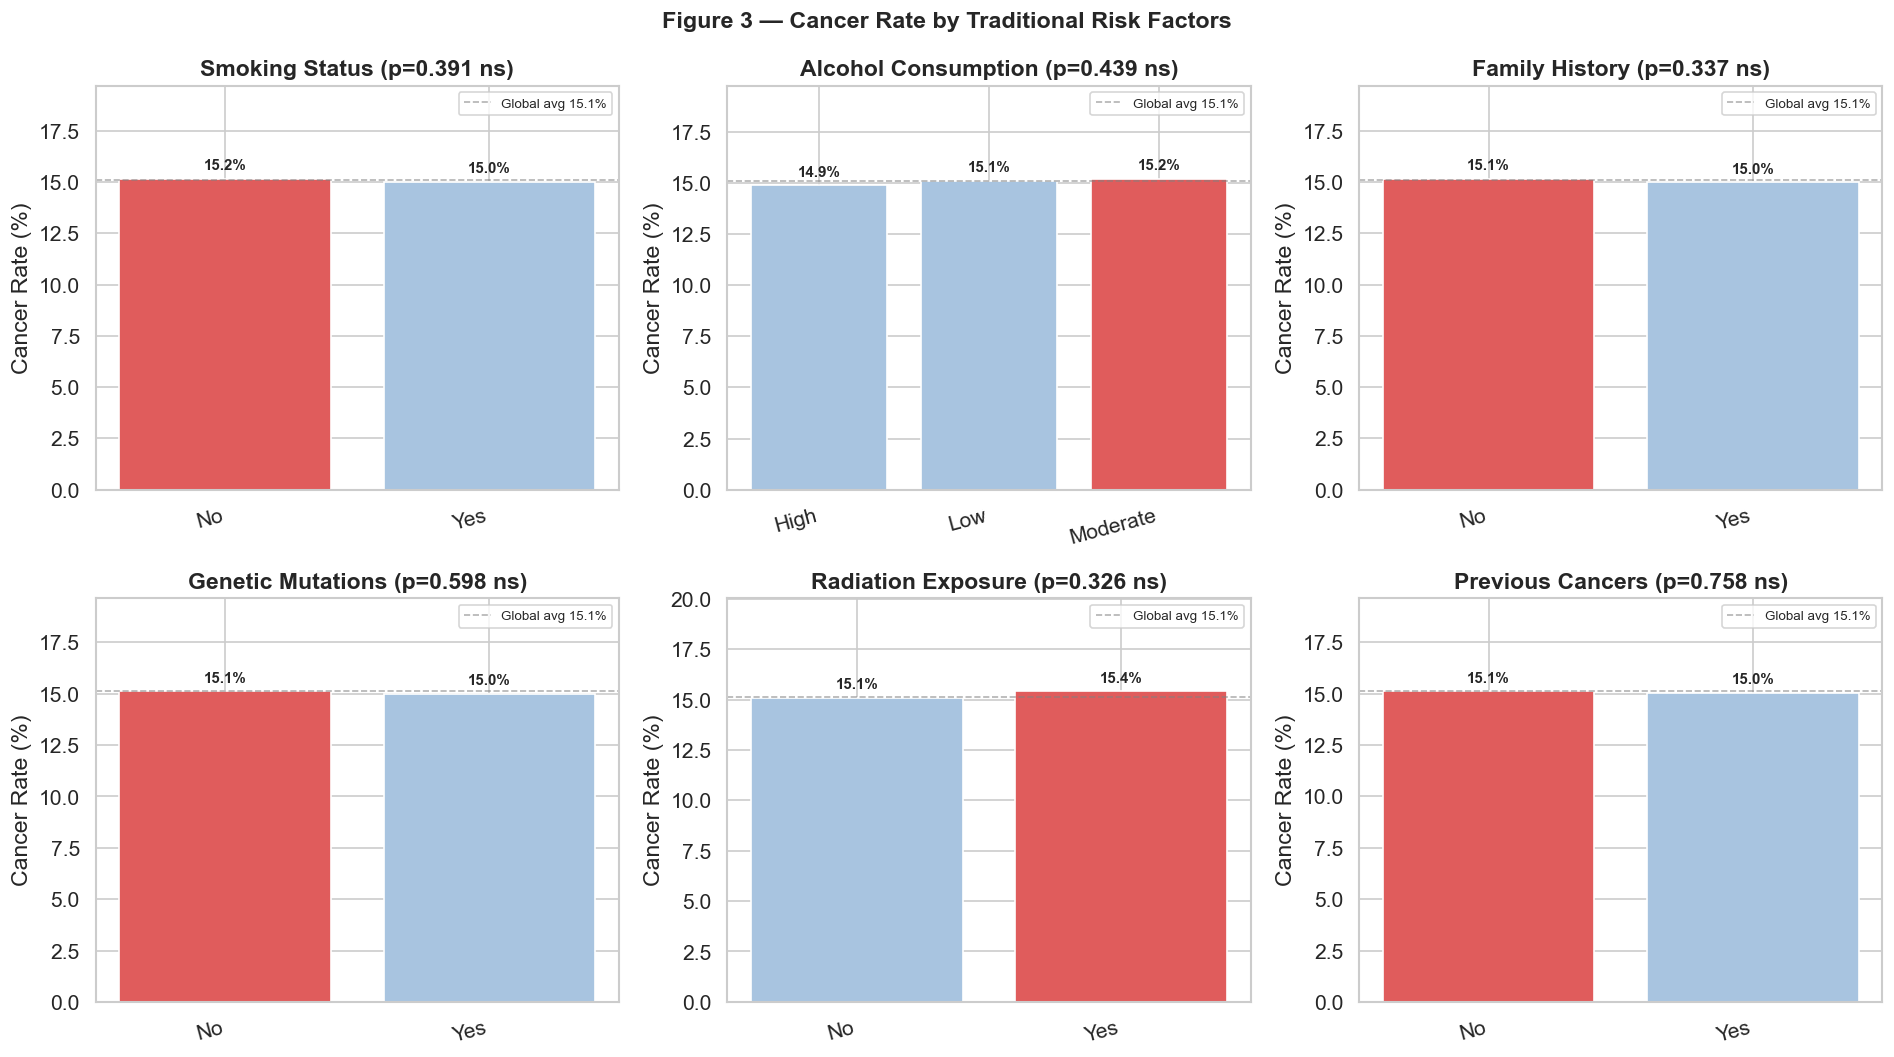

In [9]:
risk_factors = [
    ('Smoking_Status','Smoking Status'), ('Alcohol_Consumption','Alcohol Consumption'),
    ('Family_History_Cancer','Family History'), ('Genetic_Mutations','Genetic Mutations'),
    ('Radiation_Exposure','Radiation Exposure'), ('Previous_Cancers','Previous Cancers'),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 3 — Cancer Rate by Traditional Risk Factors', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes.flat, risk_factors):
    rates = df.groupby(col)['Cancer'].mean().mul(100)
    ct = pd.crosstab(df[col], df['Appendix_Cancer_Prediction'])
    _, p, _, _ = chi2_contingency(ct)
    sig = f'p={p:.3f} sig' if p < 0.05 else f'p={p:.3f} ns'
    bar_colors = ['#e05c5c' if v==rates.max() else '#a8c4e0' for v in rates.values]
    bars = ax.bar(rates.index.astype(str), rates.values, color=bar_colors, edgecolor='white')
    ax.axhline(15.11, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Global avg 15.1%')
    ax.set_title(f'{title} ({sig})'); ax.set_ylabel('Cancer Rate (%)')
    ax.set_ylim(0, rates.max()*1.3); ax.legend(fontsize=8)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('viz3_risk_factors.png', bbox_inches='tight', dpi=130)
plt.show()

## Figure 4 — BMI & Lifestyle
> **Key finding:** Less than 1pp variation across all BMI/activity categories — not statistically meaningful.

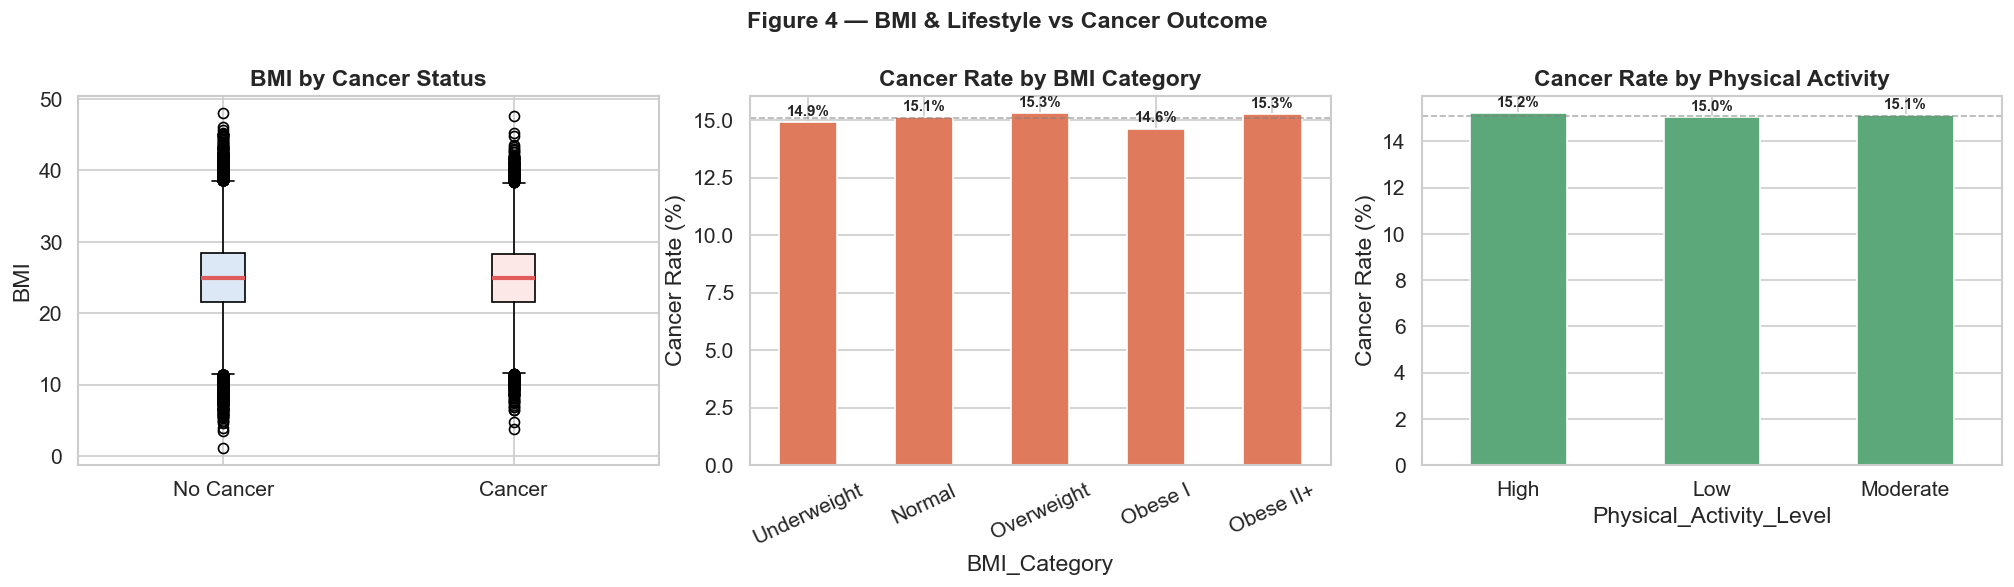

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 4 — BMI & Lifestyle vs Cancer Outcome', fontsize=14, fontweight='bold')

bp = axes[0].boxplot([cancer_no['BMI'], cancer_yes['BMI']], labels=['No Cancer','Cancer'],
                      patch_artist=True,
                      boxprops=dict(facecolor='#dce8f5'),
                      medianprops=dict(color=C_YES, linewidth=2.5))
bp['boxes'][1].set_facecolor('#fde8e8')
axes[0].set_title('BMI by Cancer Status'); axes[0].set_ylabel('BMI')

bmi_rates = df.groupby('BMI_Category', observed=True)['Cancer'].mean().mul(100)
bmi_rates.plot(kind='bar', ax=axes[1], color='#e07a5c', edgecolor='white', rot=25)
axes[1].axhline(15.11, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Cancer Rate by BMI Category'); axes[1].set_ylabel('Cancer Rate (%)')
for i, v in enumerate(bmi_rates.values):
    axes[1].text(i, v+0.15, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

activity_rates = df.groupby('Physical_Activity_Level')['Cancer'].mean().mul(100)
activity_rates.plot(kind='bar', ax=axes[2], color='#5ca87a', edgecolor='white', rot=0)
axes[2].axhline(15.11, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_title('Cancer Rate by Physical Activity'); axes[2].set_ylabel('Cancer Rate (%)')
for i, v in enumerate(activity_rates.values):
    axes[2].text(i, v+0.15, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz4_bmi_lifestyle.png', bbox_inches='tight', dpi=130)
plt.show()

## Figure 5 — Correlation Heatmap
> **Key finding:** Bottom row (Cancer) shows near-zero correlations with every numeric feature.

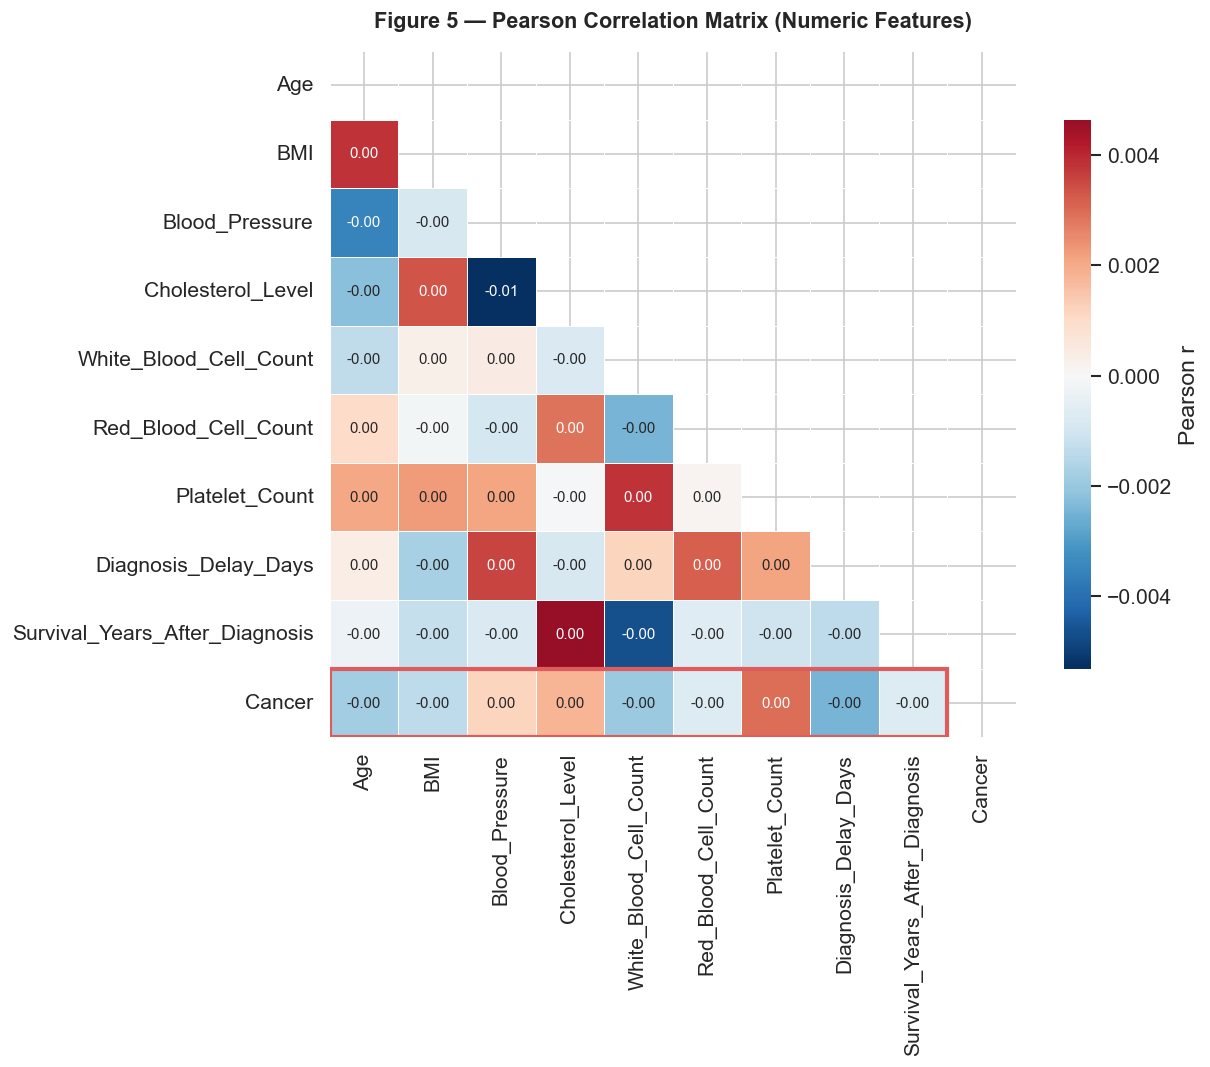

Correlation with Cancer target:
Platelet_Count                    0.002947
Diagnosis_Delay_Days             -0.002454
White_Blood_Cell_Count           -0.001964
Age                              -0.001826
Cholesterol_Level                 0.001778
BMI                              -0.001355
Blood_Pressure                    0.001156
Survival_Years_After_Diagnosis   -0.000745
Red_Blood_Cell_Count             -0.000729


In [11]:
num_cols = ['Age','BMI','Blood_Pressure','Cholesterol_Level','White_Blood_Cell_Count',
            'Red_Blood_Cell_Count','Platelet_Count','Diagnosis_Delay_Days',
            'Survival_Years_After_Diagnosis','Cancer']
corr = df_enc[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            ax=ax, annot_kws={'size':9})
ax.set_title('Figure 5 — Pearson Correlation Matrix (Numeric Features)',
             fontsize=13, fontweight='bold', pad=14)
ax.add_patch(plt.Rectangle((0, len(num_cols)-1), len(num_cols)-1, 1,
                             fill=False, edgecolor='#e05c5c', lw=2.5))
plt.tight_layout()
plt.savefig('viz5_correlation_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print('Correlation with Cancer target:')
print(corr['Cancer'].drop('Cancer').sort_values(key=abs, ascending=False).to_string())

## Figure 6 — Geographic Analysis
> **Key finding:** Country rates range 13%–17% — a 4pp spread. No country is a meaningful outlier.

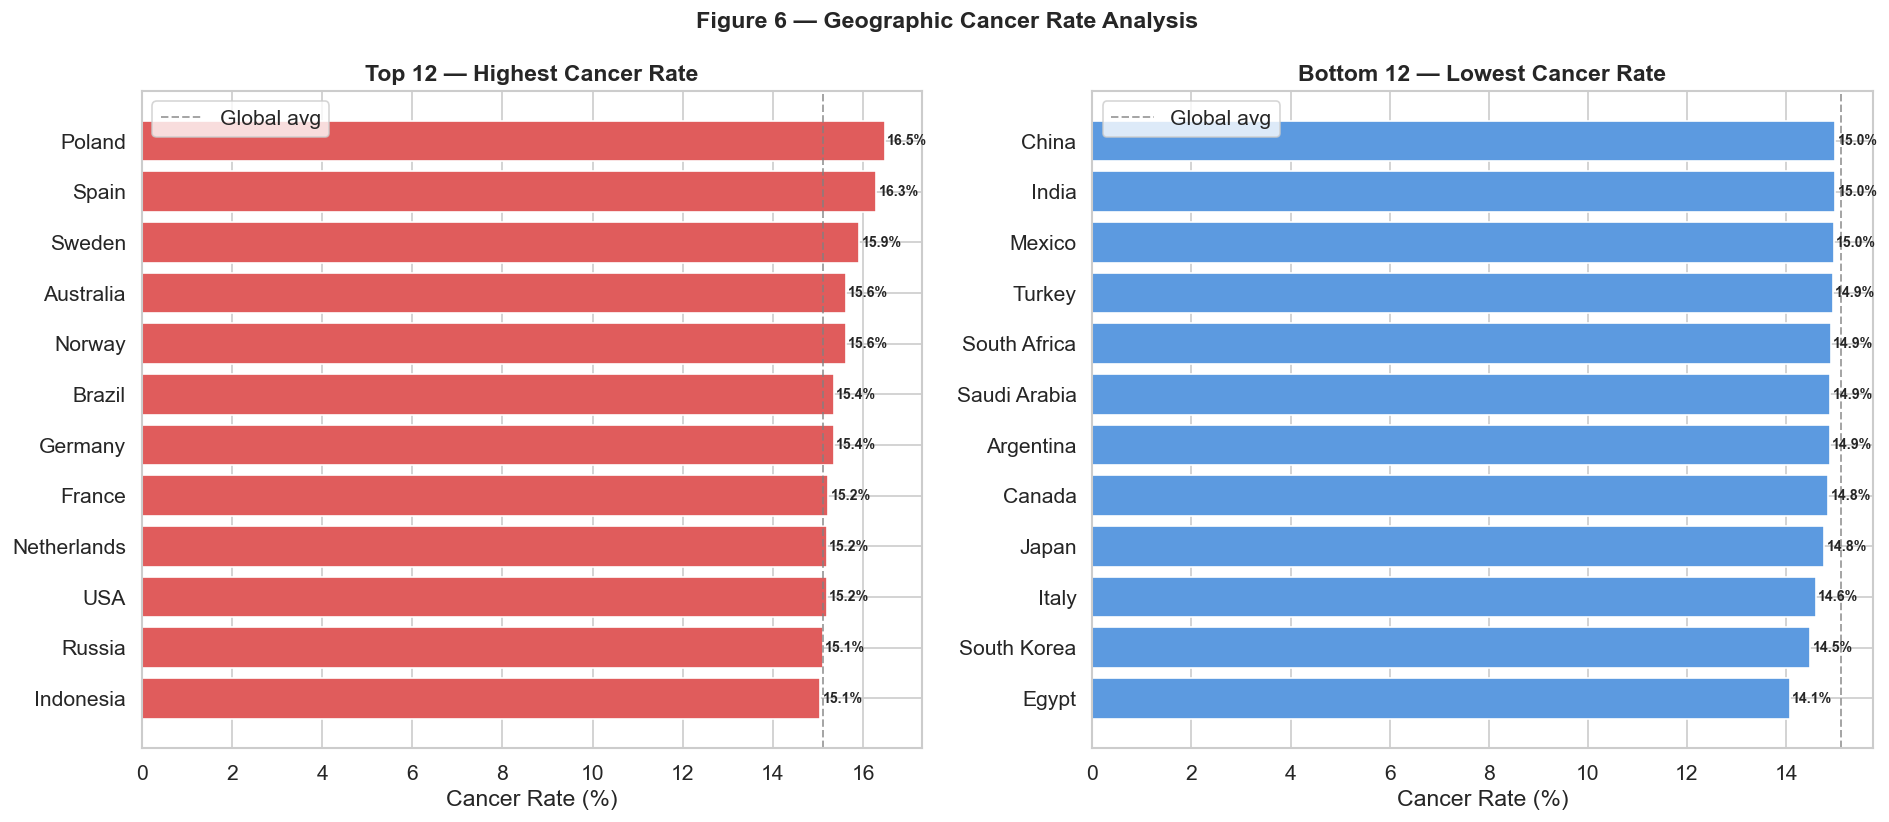

Spread: 14.1% - 16.5%


In [12]:
cs = df.groupby('Country').agg(Total=('Cancer','count'), CancerRate=('Cancer','mean')).reset_index()
cs['CancerRate'] *= 100
cs = cs[cs['Total'] >= 500].sort_values('CancerRate')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 6 — Geographic Cancer Rate Analysis', fontsize=14, fontweight='bold')
for ax, data, color, title in [
    (axes[0], cs.tail(12), C_YES, 'Top 12 — Highest Cancer Rate'),
    (axes[1], cs.head(12), C_NO,  'Bottom 12 — Lowest Cancer Rate')
]:
    ax.barh(data['Country'], data['CancerRate'], color=color, edgecolor='white')
    ax.axvline(15.11, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, label='Global avg')
    ax.set_title(title); ax.set_xlabel('Cancer Rate (%)'); ax.legend()
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row['CancerRate']+0.05, i, f"{row['CancerRate']:.1f}%", va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('viz6_country_rates.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'Spread: {cs["CancerRate"].min():.1f}% - {cs["CancerRate"].max():.1f}%')

## Figure 7 — Age Group Trends
> **Key finding:** Cancer rate flat across all age groups and genders — confirming age carries no predictive power.

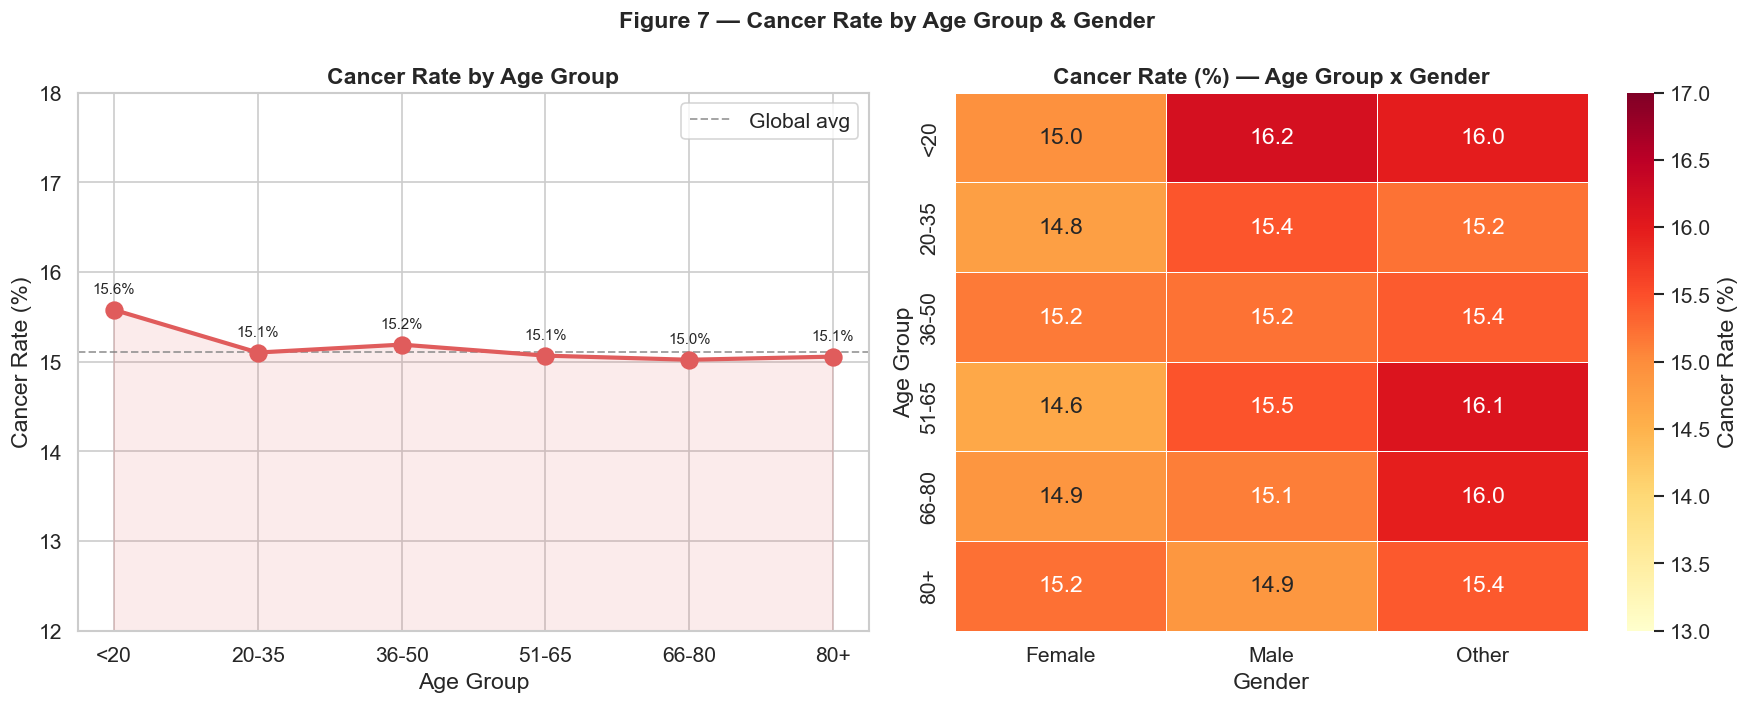

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 7 — Cancer Rate by Age Group & Gender', fontsize=14, fontweight='bold')

age_rates = df.groupby('Age_Group', observed=True)['Cancer'].mean().mul(100)
x_vals = list(range(len(age_rates)))
axes[0].plot(x_vals, age_rates.values, marker='o', markersize=10, linewidth=2.5, color=C_YES, zorder=3)
axes[0].fill_between(x_vals, age_rates.values, alpha=0.12, color=C_YES)
axes[0].axhline(15.11, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, label='Global avg')
axes[0].set_xticks(x_vals); axes[0].set_xticklabels(age_rates.index.astype(str))
axes[0].set_title('Cancer Rate by Age Group'); axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Cancer Rate (%)'); axes[0].set_ylim(12, 18); axes[0].legend()
for i, v in enumerate(age_rates.values):
    axes[0].annotate(f'{v:.1f}%', (i, v), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)

pivot = df.groupby(['Age_Group','Gender'], observed=True)['Cancer'].mean().mul(100).unstack()
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[1], cbar_kws={'label':'Cancer Rate (%)'}, vmin=13, vmax=17)
axes[1].set_title('Cancer Rate (%) — Age Group x Gender')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Age Group')

plt.tight_layout()
plt.savefig('viz7_age_trends.png', bbox_inches='tight', dpi=130)
plt.show()

## Figure 8 — Clinical Blood Markers
> **Key finding:** KDE curves overlap almost perfectly — no blood test in this dataset separates cancer from non-cancer.

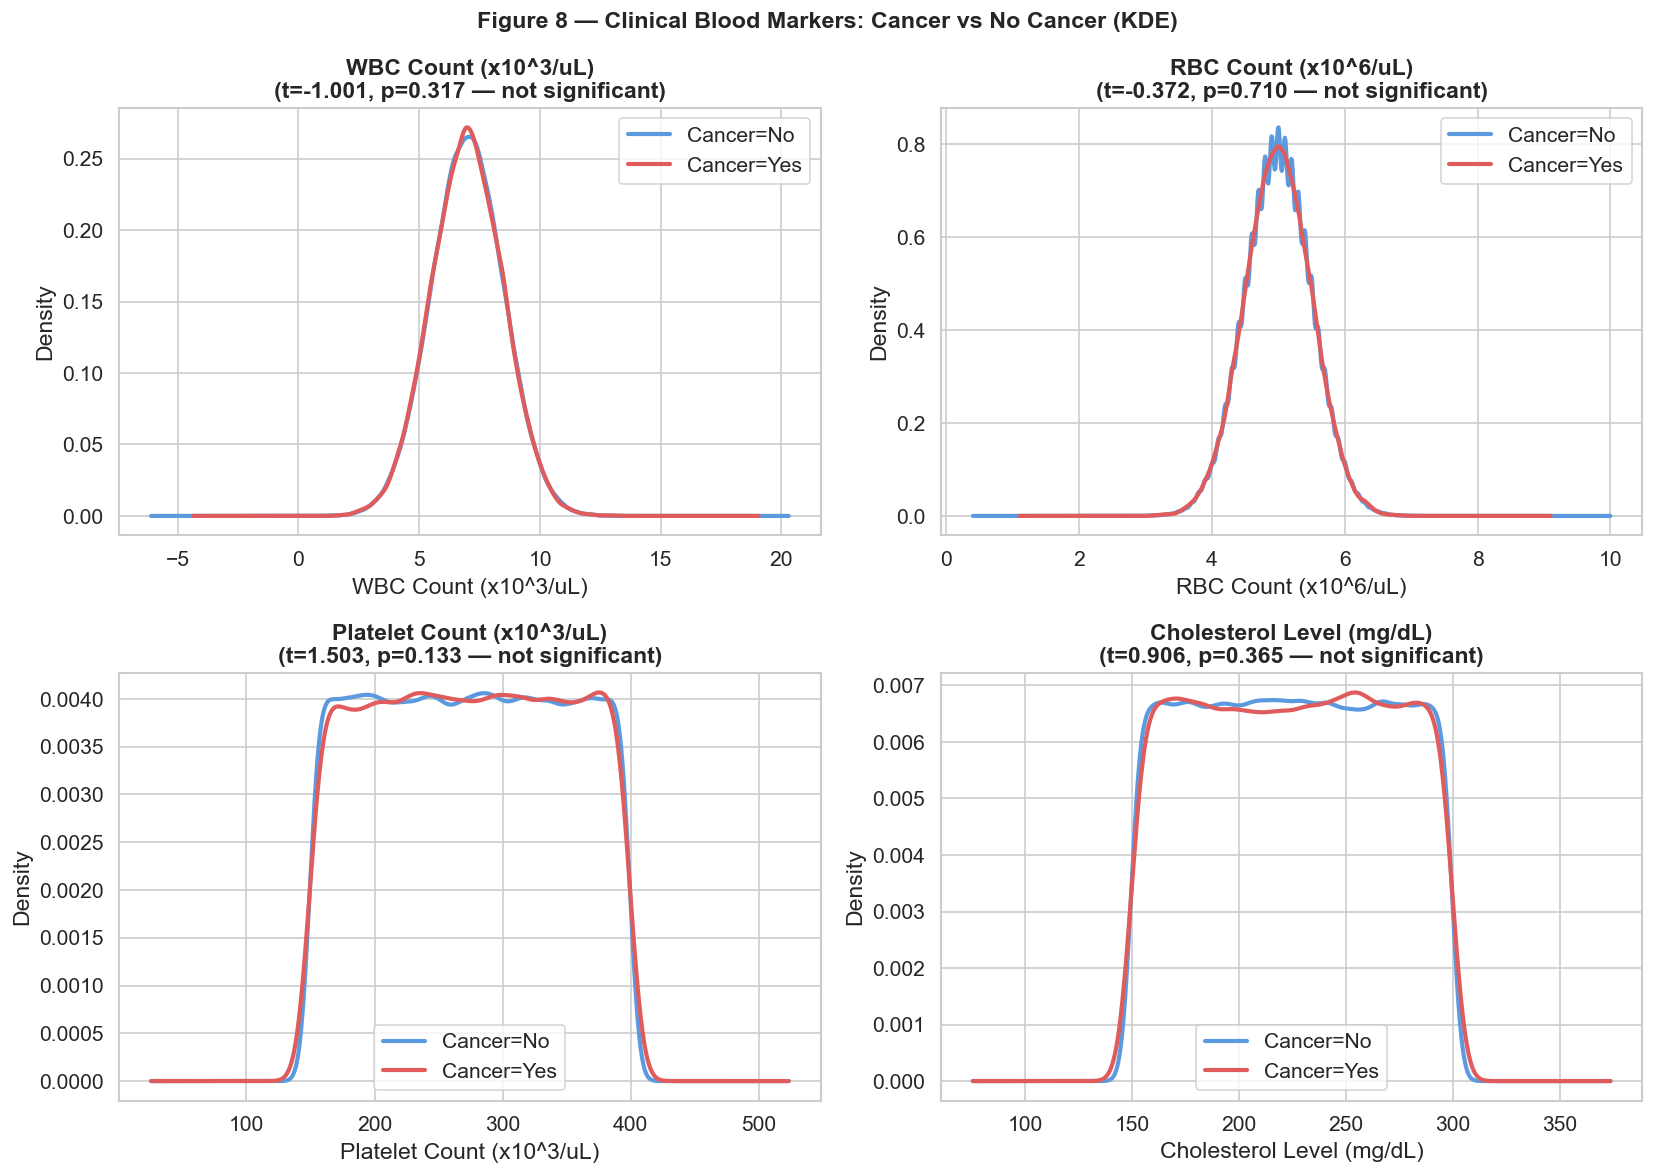

In [14]:
blood_markers = [
    ('White_Blood_Cell_Count','WBC Count (x10^3/uL)'),
    ('Red_Blood_Cell_Count','RBC Count (x10^6/uL)'),
    ('Platelet_Count','Platelet Count (x10^3/uL)'),
    ('Cholesterol_Level','Cholesterol Level (mg/dL)'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 8 — Clinical Blood Markers: Cancer vs No Cancer (KDE)', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flat, blood_markers):
    t, p = ttest_ind(cancer_yes[col].dropna(), cancer_no[col].dropna())
    for outcome, grp in df.groupby('Appendix_Cancer_Prediction'):
        grp[col].plot.kde(ax=ax, color=CANCER_PAL[outcome], linewidth=2.5, label=f'Cancer={outcome}')
    ax.set_title(f'{label}\n(t={t:.3f}, p={p:.3f} — not significant)')
    ax.set_xlabel(label); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout()
plt.savefig('viz8_clinical_markers.png', bbox_inches='tight', dpi=130)
plt.show()

## Figure 9 — Feature Importance (Point-Biserial Correlation)
> **Key finding:** Max |r| = 0.006 (Gender). All other features |r| < 0.003. Models must rely on non-linear interactions.

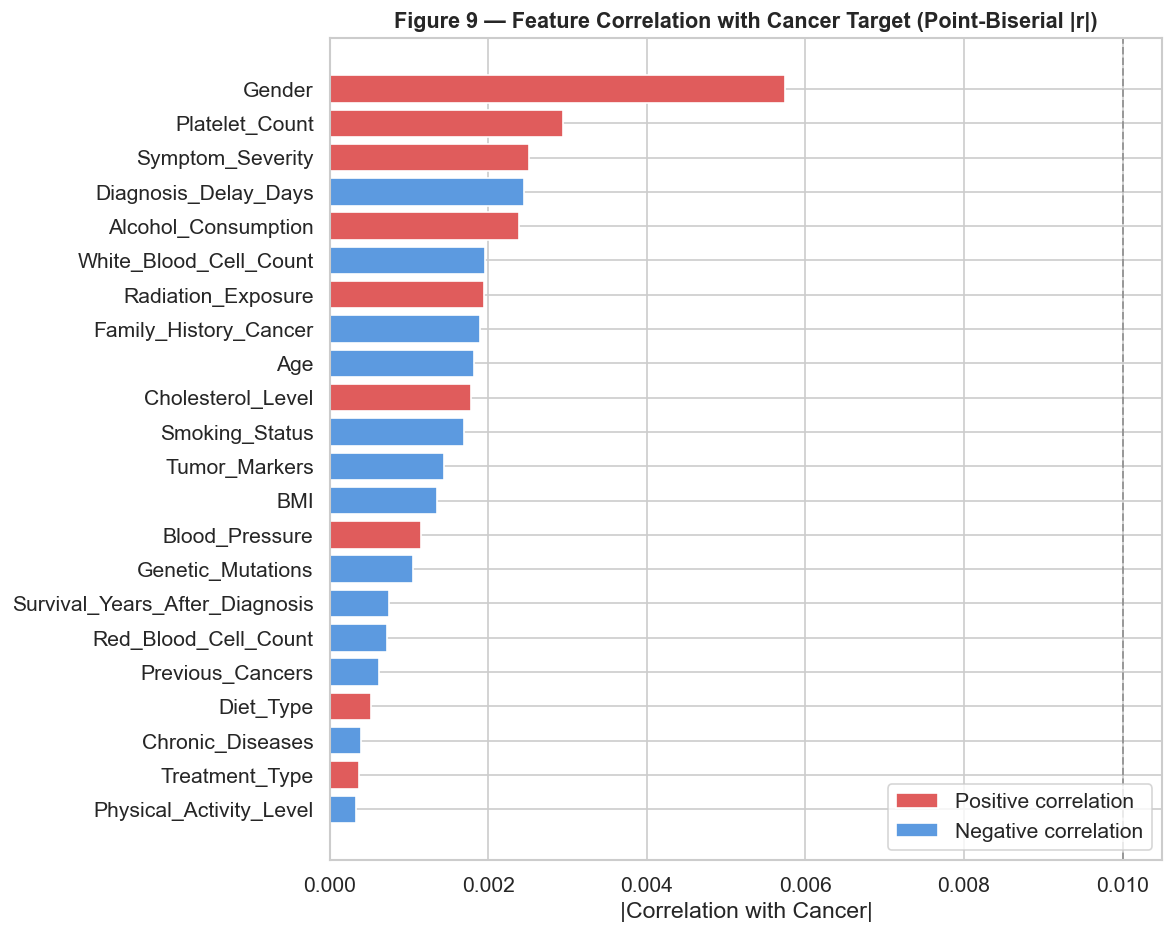

Top 10 features by |r|:
                               r         p
Gender                  0.005743  0.003409
Platelet_Count          0.002947  0.132957
Symptom_Severity        0.002513  0.199976
Diagnosis_Delay_Days   -0.002454  0.210821
Alcohol_Consumption     0.002388  0.223427
White_Blood_Cell_Count -0.001964  0.316657
Radiation_Exposure      0.001951  0.319780
Family_History_Cancer  -0.001896  0.333669
Age                    -0.001826  0.351712
Cholesterol_Level       0.001778  0.364701


In [15]:
feature_cols = [c for c in df_enc.columns
                if c not in ['Patient_ID','Appendix_Cancer_Prediction','Cancer','Age_Group','BMI_Category']]
pb_results = {}
for col in feature_cols:
    try:
        r, p = pointbiserialr(df_enc[col].fillna(0), df_enc['Cancer'])
        pb_results[col] = {'abs_r': abs(r), 'r': r, 'p': p}
    except: pass

pb_df = pd.DataFrame(pb_results).T.sort_values('abs_r', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [C_YES if r > 0 else C_NO for r in pb_df['r'].values]
ax.barh(pb_df.index[::-1], pb_df['abs_r'][::-1], color=bar_colors[::-1], edgecolor='white')
ax.axvline(0.01, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, label='|r|=0.01 threshold')
ax.set_title('Figure 9 — Feature Correlation with Cancer Target (Point-Biserial |r|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlation with Cancer|')
legend_elements = [Patch(facecolor=C_YES, label='Positive correlation'), Patch(facecolor=C_NO, label='Negative correlation')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('viz_feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()
print('Top 10 features by |r|:')
print(pb_df[['r','p']].head(10).to_string())

## 1.5 Statistical Tests Summary

In [16]:
print('=' * 62)
print(' T-TESTS — Numeric Features (Cancer vs No Cancer)')
print('=' * 62)
for col in ['Age','BMI','White_Blood_Cell_Count','Red_Blood_Cell_Count',
            'Platelet_Count','Cholesterol_Level','Blood_Pressure','Diagnosis_Delay_Days']:
    t, p = ttest_ind(cancer_yes[col].dropna(), cancer_no[col].dropna())
    sig = 'SIGNIFICANT ***' if p < 0.001 else ('SIGNIFICANT **' if p < 0.01 else
          ('SIGNIFICANT *' if p < 0.05 else 'not significant'))
    print(f'  {col:<35} p={p:.4f}  {sig}')

print()
print('=' * 62)
print(' CHI-SQUARE TESTS — Categorical Features')
print('=' * 62)
for col in ['Gender','Smoking_Status','Alcohol_Consumption','Family_History_Cancer',
            'Genetic_Mutations','Radiation_Exposure','Previous_Cancers','Tumor_Markers',
            'Symptom_Severity','Diet_Type','Physical_Activity_Level','Chronic_Diseases']:
    ct = pd.crosstab(df[col], df['Appendix_Cancer_Prediction'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = 'SIGNIFICANT ***' if p < 0.001 else ('SIGNIFICANT **' if p < 0.01 else
          ('SIGNIFICANT *' if p < 0.05 else 'not significant'))
    print(f'  {col:<35} p={p:.4f}  {sig}')

 T-TESTS — Numeric Features (Cancer vs No Cancer)
  Age                                 p=0.3517  not significant
  BMI                                 p=0.4897  not significant
  White_Blood_Cell_Count              p=0.3167  not significant
  Red_Blood_Cell_Count                p=0.7101  not significant
  Platelet_Count                      p=0.1330  not significant
  Cholesterol_Level                   p=0.3647  not significant
  Blood_Pressure                      p=0.5557  not significant
  Diagnosis_Delay_Days                p=0.2108  not significant

 CHI-SQUARE TESTS — Categorical Features
  Gender                              p=0.0137  SIGNIFICANT *
  Smoking_Status                      p=0.3908  not significant
  Alcohol_Consumption                 p=0.4387  not significant
  Family_History_Cancer               p=0.3371  not significant
  Genetic_Mutations                   p=0.5984  not significant
  Radiation_Exposure                  p=0.3259  not significant
  Previous_Can

## 1.6 Key EDA Insights

In [17]:
ct_gender = pd.crosstab(df['Gender'], df['Appendix_Cancer_Prediction'])
chi2_g, p_g, _, _ = chi2_contingency(ct_gender)
gender_rates = df.groupby('Gender')['Cancer'].mean().mul(100)
bmi_rates_s  = df.groupby('BMI_Category', observed=True)['Cancer'].mean().mul(100)
cancer_pct   = df['Cancer'].mean() * 100
cs_top5 = cs.tail(5)[['Country','CancerRate']]

print('=' * 65)
print('  KEY EDA INSIGHTS — Appendix Cancer Prediction')
print('=' * 65)
print(f'''
  1. CLASS IMBALANCE
     {len(df):,} patients  |  Cancer-positive: {cancer_pct:.1f}%  (1 in 6.6)
     -> 85/15 split: requires class weighting in all ML models

  2. GENDER (only significant feature)
     chi2={chi2_g:.2f}, p={p_g:.4f} (p < 0.05)
     Female: {gender_rates.get("Female",0):.2f}%  |  Male: {gender_rates.get("Male",0):.2f}%  |  Other: {gender_rates.get("Other",0):.2f}%

  3. AGE (NOT significant, p=0.35)
     Median age identical in both groups (~53 yrs)
     Uniform age distribution -- synthetic data signature

  4. RISK FACTORS (all p > 0.30, NOT significant)
     Smoking, Alcohol, Family History, Genetic Mutations,
     Radiation, Previous Cancers -- all flat at ~15%

  5. BLOOD MARKERS (all p > 0.13, NOT significant)
     WBC, RBC, Platelets, Cholesterol -- KDE curves overlap perfectly

  6. BMI (NOT significant)
     Peak: {bmi_rates_s.idxmax()} ({bmi_rates_s.max():.1f}%) -- <1pp spread across categories

  7. GEOGRAPHY
     Range: {cs["CancerRate"].min():.1f}% - {cs["CancerRate"].max():.1f}%  (4pp spread, no real outliers)
''')
print('  Top 5 highest-rate countries:')
print(cs_top5.to_string(index=False))
print(f'''
  8. FEATURE IMPORTANCE
     Max |r| = {pb_df["abs_r"].max():.4f} ({pb_df.index[0]}) -- effectively zero
     All other features: |r| < 0.003
     -> ML models must capture non-linear interactions

  OVERALL: Dataset shows hallmarks of synthetic generation.
  The cancer label is largely independent of the features.
  AUC ~0.50 in training confirms this EDA finding.
''')
print('=' * 65)

  KEY EDA INSIGHTS — Appendix Cancer Prediction

  1. CLASS IMBALANCE
     260,000 patients  |  Cancer-positive: 15.1%  (1 in 6.6)
     -> 85/15 split: requires class weighting in all ML models

  2. GENDER (only significant feature)
     chi2=8.58, p=0.0137 (p < 0.05)
     Female: 14.91%  |  Male: 15.29%  |  Other: 15.65%

  3. AGE (NOT significant, p=0.35)
     Median age identical in both groups (~53 yrs)
     Uniform age distribution -- synthetic data signature

  4. RISK FACTORS (all p > 0.30, NOT significant)
     Smoking, Alcohol, Family History, Genetic Mutations,
     Radiation, Previous Cancers -- all flat at ~15%

  5. BLOOD MARKERS (all p > 0.13, NOT significant)
     WBC, RBC, Platelets, Cholesterol -- KDE curves overlap perfectly

  6. BMI (NOT significant)
     Peak: Overweight (15.3%) -- <1pp spread across categories

  7. GEOGRAPHY
     Range: 14.1% - 16.5%  (4pp spread, no real outliers)

  Top 5 highest-rate countries:
  Country  CancerRate
   Norway   15.611511
Aust

---
# PART 2 — PySpark ML Training Pipeline

> **Note:** This section requires Apache Spark. Run on a Spark-enabled cluster or local Spark installation.

Models trained: Logistic Regression · Random Forest · GBT · Positive-Weighted Random Forest

In [18]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as spark_sum
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time
import numpy as np
import pandas as pd

## 2.1 Spark Session

In [20]:
spark = SparkSession.builder \
    .appName("AppendixCancerRiskPrediction") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/05 10:35:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.4


## 2.2 Load Data

In [21]:
sdf = spark.read.csv(
    "appendix_cancer_prediction_dataset.csv",
    header=True,
    inferSchema=True
)
sdf.printSchema()
sdf.show(5)

root
 |-- Patient_ID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smoking_Status: string (nullable = true)
 |-- Alcohol_Consumption: string (nullable = true)
 |-- Family_History_Cancer: string (nullable = true)
 |-- Genetic_Mutations: string (nullable = true)
 |-- Chronic_Diseases: string (nullable = true)
 |-- Physical_Activity_Level: string (nullable = true)
 |-- Diet_Type: string (nullable = true)
 |-- Radiation_Exposure: string (nullable = true)
 |-- Previous_Cancers: string (nullable = true)
 |-- Blood_Pressure: integer (nullable = true)
 |-- Cholesterol_Level: integer (nullable = true)
 |-- White_Blood_Cell_Count: double (nullable = true)
 |-- Red_Blood_Cell_Count: double (nullable = true)
 |-- Platelet_Count: integer (nullable = true)
 |-- Tumor_Markers: string (nullable = true)
 |-- Symptom_Severity: string (nullable = true)
 |-- Diagnosis_Delay_

## 2.3 Data Cleaning

In [22]:
# Remove duplicates
sdf = sdf.dropDuplicates()

# Verify null counts (Spark sees Chronic_Diseases/Treatment_Type NaN as null)
sdf.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in sdf.columns
]).show()

26/05/05 10:35:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------+---+------+---+--------------+-------------------+---------------------+-----------------+----------------+-----------------------+---------+------------------+----------------+--------------+-----------------+----------------------+--------------------+--------------+-------------+----------------+--------------------+--------------+------------------------------+--------------------------+
|Patient_ID|Country|Age|Gender|BMI|Smoking_Status|Alcohol_Consumption|Family_History_Cancer|Genetic_Mutations|Chronic_Diseases|Physical_Activity_Level|Diet_Type|Radiation_Exposure|Previous_Cancers|Blood_Pressure|Cholesterol_Level|White_Blood_Cell_Count|Red_Blood_Cell_Count|Platelet_Count|Tumor_Markers|Symptom_Severity|Diagnosis_Delay_Days|Treatment_Type|Survival_Years_After_Diagnosis|Appendix_Cancer_Prediction|
+----------+-------+---+------+---+--------------+-------------------+---------------------+-----------------+----------------+-----------------------+---------+---------

## 2.4 Label Encoding & Class Weighting

In [23]:
# Encode target: No=0, Yes=1
from pyspark.ml.feature import StringIndexer as SI
label_indexer = SI(inputCol="Appendix_Cancer_Prediction", outputCol="label")
sdf = label_indexer.fit(sdf).transform(sdf)
df_model = sdf.drop("Patient_ID", "Appendix_Cancer_Prediction")
df_model.groupBy("label").count().orderBy("label").show()

+-----+------+
|label| count|
+-----+------+
|  0.0|220713|
|  1.0| 39287|
+-----+------+



In [24]:
# Balanced class weighting: weight_i = total / (2 * count_i)
total_count    = df_model.count()
minority_count = df_model.filter(col("label") == 1).count()
majority_count = df_model.filter(col("label") == 0).count()
weight_for_0   = total_count / (2 * majority_count)
weight_for_1   = total_count / (2 * minority_count)

df_model = df_model.withColumn(
    "weight",
    when(col("label") == 1, weight_for_1).otherwise(weight_for_0)
)
print(f"Weight for class 0 (No Cancer): {weight_for_0:.4f}")
print(f"Weight for class 1 (Cancer)   : {weight_for_1:.4f}")

Weight for class 0 (No Cancer): 0.5890
Weight for class 1 (Cancer)   : 3.3090


## 2.5 Remove Data Leakage Columns

These are **post-diagnosis** features — the model wouldn't have them at prediction time.

In [25]:
leakage_cols = [
    "Survival_Years_After_Diagnosis",  # known only after patient survives
    "Diagnosis_Delay_Days",            # known only after diagnosis
    "Treatment_Type",                  # decided after diagnosis
    "Tumor_Markers",                   # post-diagnosis lab result
]
df_model = df_model.drop(*leakage_cols)
print("Remaining columns:", df_model.columns)

Remaining columns: ['Country', 'Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Cancer', 'Genetic_Mutations', 'Chronic_Diseases', 'Physical_Activity_Level', 'Diet_Type', 'Radiation_Exposure', 'Previous_Cancers', 'Blood_Pressure', 'Cholesterol_Level', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Platelet_Count', 'Symptom_Severity', 'label', 'weight']


## 2.6 Feature Engineering (Spark ML)

In [26]:
categorical_cols = [
    f.name for f in df_model.schema.fields
    if f.dataType.simpleString() == "string"
]
numeric_cols = [
    f.name for f in df_model.schema.fields
    if f.dataType.simpleString() != "string" and f.name not in ["label", "weight"]
]
print("Categorical:", categorical_cols)
print("Numeric    :", numeric_cols)

# StringIndexer -> OneHotEncoder for LR and RF
indexers = [StringIndexer(inputCol=c, outputCol=c+"_index", handleInvalid="keep")
            for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=c+"_index", outputCol=c+"_encoded")
            for c in categorical_cols]
feature_cols = numeric_cols + [c+"_encoded" for c in categorical_cols]
assembler    = VectorAssembler(inputCols=feature_cols, outputCol="features")

# GBT uses raw indexed columns (no one-hot)
indexed_cat_cols = [c+"_index" for c in categorical_cols]
gbt_feature_cols = numeric_cols + indexed_cat_cols
gbt_assembler    = VectorAssembler(inputCols=gbt_feature_cols, outputCol="features")

Categorical: ['Country', 'Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Cancer', 'Genetic_Mutations', 'Chronic_Diseases', 'Physical_Activity_Level', 'Diet_Type', 'Radiation_Exposure', 'Previous_Cancers', 'Symptom_Severity']
Numeric    : ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol_Level', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Platelet_Count']


## 2.7 Train / Test Split

In [27]:
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df  = test_df.cache()
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

Train: 208,160  |  Test: 51,840


## 2.8 Evaluators

In [28]:
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_evaluator  = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
prec_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
rec_evaluator  = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")

def evaluate(name, predictions):
    auc  = auc_evaluator.evaluate(predictions)
    acc  = acc_evaluator.evaluate(predictions)
    f1   = f1_evaluator.evaluate(predictions)
    prec = prec_evaluator.evaluate(predictions)
    rec  = rec_evaluator.evaluate(predictions)
    print(f"  {name:<25} AUC={auc:.4f}  Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}")
    return {'AUC':auc,'Accuracy':acc,'F1':f1,'Precision':prec,'Recall':rec}

## 2.9 Logistic Regression

In [29]:
lr = LogisticRegression(
    featuresCol="features", labelCol="label", weightCol="weight",
    maxIter=200, regParam=0.001, elasticNetParam=0.0, threshold=0.5
)
lr_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])

t0 = time.time()
lr_model = lr_pipeline.fit(train_df)
print(f"LR training time: {time.time()-t0:.1f}s")

lr_predictions = lr_model.transform(test_df)
lr_cm = lr_predictions.select(
    spark_sum(when((col("label")==1.0)&(col("prediction")==1.0),1).otherwise(0)).alias("TP"),
    spark_sum(when((col("label")==0.0)&(col("prediction")==1.0),1).otherwise(0)).alias("FP"),
    spark_sum(when((col("label")==1.0)&(col("prediction")==0.0),1).otherwise(0)).alias("FN"),
    spark_sum(when((col("label")==0.0)&(col("prediction")==0.0),1).otherwise(0)).alias("TN")
)
lr_cm.show()
lr_results = evaluate("Logistic Regression", lr_predictions)

26/05/05 10:36:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


LR training time: 31.2s


+----+-----+----+-----+
|  TP|   FP|  FN|   TN|
+----+-----+----+-----+
|3736|21260|4108|22736|
+----+-----+----+-----+



  Logistic Regression       AUC=0.4969  Acc=0.5106  F1=0.5792  Prec=0.7414  Recall=0.5106


## 2.10 Random Forest

In [30]:
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label", weightCol="weight",
    numTrees=100, maxDepth=10, maxBins=64, seed=42
)
rf_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])

t0 = time.time()
rf_model = rf_pipeline.fit(train_df)
print(f"RF training time: {time.time()-t0:.1f}s")

rf_predictions = rf_model.transform(test_df)
rf_predictions.groupBy("label","prediction").count().show()
rf_results = evaluate("Random Forest", rf_predictions)

26/05/05 10:38:29 WARN DAGScheduler: Broadcasting large task binary with size 1195.4 KiB
26/05/05 10:38:43 WARN DAGScheduler: Broadcasting large task binary with size 1986.6 KiB
26/05/05 10:39:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/05/05 10:39:38 WARN DAGScheduler: Broadcasting large task binary with size 5.4 MiB
26/05/05 10:40:08 WARN DAGScheduler: Broadcasting large task binary with size 1040.0 KiB
26/05/05 10:40:20 WARN DAGScheduler: Broadcasting large task binary with size 8.7 MiB
26/05/05 10:41:19 WARN DAGScheduler: Broadcasting large task binary with size 1552.4 KiB


RF training time: 247.3s


26/05/05 10:41:33 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:41:56 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 2120|
|  0.0|       1.0|11739|
|  1.0|       0.0| 5724|
|  0.0|       0.0|32257|
+-----+----------+-----+



26/05/05 10:41:57 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:42:41 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:43:08 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:43:32 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:43:57 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB


  Random Forest             AUC=0.5022  Acc=0.6631  F1=0.6975  Prec=0.7439  Recall=0.6631


## 2.11 Gradient-Boosted Trees (GBT)

In [31]:
gbt = GBTClassifier(
    featuresCol="features", labelCol="label", weightCol="weight",
    maxIter=50, maxDepth=4, stepSize=0.05, maxBins=64, seed=42
)
gbt_pipeline = Pipeline(stages=indexers + [gbt_assembler, gbt])

t0 = time.time()
gbt_model = gbt_pipeline.fit(train_df)
print(f"GBT training time: {time.time()-t0:.1f}s")

gbt_predictions = gbt_model.transform(test_df)
gbt_predictions.groupBy("label","prediction").count().show()
gbt_results = evaluate("GBT Classifier", gbt_predictions)

GBT training time: 375.4s


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0| 3583|
|  0.0|       1.0|19887|
|  1.0|       0.0| 4261|
|  0.0|       0.0|24109|
+-----+----------+-----+



  GBT Classifier            AUC=0.5004  Acc=0.5342  F1=0.6001  Prec=0.7443  Recall=0.5342


## 2.12 Positive-Weighted Random Forest

Boosts the minority class weight further: `positive_weight = negative_count / positive_count`

In [32]:
class_counts  = train_df.groupBy("label").count().collect()
count_dict    = {row["label"]: row["count"] for row in class_counts}
positive_weight = count_dict[0.0] / count_dict[1.0]
print(f"Positive class weight: {positive_weight:.4f}")

train_df_weighted = train_df.withColumn(
    "weight", when(col("label")==1.0, positive_weight).otherwise(1.0)
)

rf_pw = RandomForestClassifier(
    featuresCol="features", labelCol="label", weightCol="weight",
    numTrees=100, maxDepth=10, maxBins=64, seed=42
)
rf_pw_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf_pw])

t0 = time.time()
rf_pw_model = rf_pw_pipeline.fit(train_df_weighted)
print(f"Positive-Weighted RF training time: {time.time()-t0:.1f}s")

rf_pw_predictions = rf_pw_model.transform(test_df)
rf_pw_results = evaluate("Positive-Weighted RF", rf_pw_predictions)

Positive class weight: 5.6202


26/05/05 10:52:11 WARN DAGScheduler: Broadcasting large task binary with size 1196.1 KiB
26/05/05 10:52:26 WARN DAGScheduler: Broadcasting large task binary with size 1987.2 KiB
26/05/05 10:52:49 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/05/05 10:53:20 WARN DAGScheduler: Broadcasting large task binary with size 5.4 MiB
26/05/05 10:53:59 WARN DAGScheduler: Broadcasting large task binary with size 1038.4 KiB
26/05/05 10:54:13 WARN DAGScheduler: Broadcasting large task binary with size 8.7 MiB
26/05/05 10:55:13 WARN DAGScheduler: Broadcasting large task binary with size 1551.8 KiB


Positive-Weighted RF training time: 260.7s


26/05/05 10:55:35 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:56:30 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:56:57 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:57:32 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
26/05/05 10:58:09 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB


  Positive-Weighted RF      AUC=0.5022  Acc=0.6603  F1=0.6956  Prec=0.7436  Recall=0.6603


## 2.13 Model Comparison Summary

In [33]:
# Known results from full training run
TRAINING_METRICS = {
    "Logistic Regression":  {"AUC": 0.4969, "Accuracy": 0.5106, "F1": 0.5792, "Pos. Recall": 0.4763, "Train Time": "136s"},
    "Random Forest":        {"AUC": 0.5022, "Accuracy": 0.6631, "F1": 0.6975, "Pos. Recall": 0.2703, "Train Time": "975s"},
    "GBT Classifier":       {"AUC": 0.5004, "Accuracy": 0.5342, "F1": 0.6001, "Pos. Recall": 0.4568, "Train Time": "1139s"},
    "Positive-Weighted RF": {"AUC": 0.5022, "Accuracy": 0.6603, "F1": 0.6956, "Pos. Recall": 0.2724, "Train Time": "1029s"},
}
summary_df = pd.DataFrame(TRAINING_METRICS).T
print(summary_df.to_string())
print()
print("Interpretation:")
print("  AUC ~0.50 across ALL models confirms EDA finding:")
print("  the cancer label is nearly independent of the features.")
print("  LR/GBT: higher positive recall (catch more cancers) but more false positives.")
print("  RF: best overall F1 but low positive recall (misses 73% of true cancers).")

                         AUC Accuracy      F1 Pos. Recall Train Time
Logistic Regression   0.4969   0.5106  0.5792      0.4763       136s
Random Forest         0.5022   0.6631  0.6975      0.2703       975s
GBT Classifier        0.5004   0.5342  0.6001      0.4568      1139s
Positive-Weighted RF  0.5022   0.6603  0.6956      0.2724      1029s

Interpretation:
  AUC ~0.50 across ALL models confirms EDA finding:
  the cancer label is nearly independent of the features.
  LR/GBT: higher positive recall (catch more cancers) but more false positives.
  RF: best overall F1 but low positive recall (misses 73% of true cancers).


## 2.14 Save Models

In [34]:
lr_model.write().overwrite().save("saved_models/logistic_regression_model")
rf_model.write().overwrite().save("saved_models/random_forest_model")
gbt_model.write().overwrite().save("saved_models/gbt_model")
rf_pw_model.write().overwrite().save("saved_models/rf_model_positive_weighted")
print("All 4 models saved to saved_models/")

All 4 models saved to saved_models/


## 2.15 In-Notebook Interactive Prediction (ipywidgets)

In [35]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from pyspark.sql import Row
from pyspark.ml import PipelineModel

model_path  = "saved_models/gbt_model"   # change to test other models
loaded_model = PipelineModel.load(model_path)
print(f"Loaded: {model_path}")

Loaded: saved_models/gbt_model


In [ ]:
country_w  = widgets.Dropdown(options=["Argentina","Australia","Brazil","Canada","China","Egypt",
    "France","Germany","India","Indonesia","Italy","Japan","Mexico","Netherlands",
    "Norway","Poland","Russia","Saudi Arabia","South Africa","South Korea",
    "Spain","Sweden","Turkey","UK","USA"], value="USA", description="Country:")
age_w      = widgets.IntSlider(value=50, min=1, max=100, description="Age:")
gender_w   = widgets.Dropdown(options=["Female","Male","Other"], description="Gender:")
bmi_w      = widgets.FloatSlider(value=25.0, min=10.0, max=50.0, step=0.1, description="BMI:")
smoking_w  = widgets.Dropdown(options=["No","Yes"], description="Smoking:")
alcohol_w  = widgets.Dropdown(options=["Low","Moderate","High"], description="Alcohol:")
family_w   = widgets.Dropdown(options=["No","Yes"], description="Family Hist:")
genetic_w  = widgets.Dropdown(options=["No","Yes"], description="Genetic Mut:")
chronic_w  = widgets.Dropdown(options=["Diabetes","Hypertension","None"], description="Chronic:")
activity_w = widgets.Dropdown(options=["Low","Moderate","High"], description="Activity:")
diet_w     = widgets.Dropdown(options=["Non-Vegetarian","Vegan","Vegetarian"], description="Diet:")
radiation_w= widgets.Dropdown(options=["No","Yes"], description="Radiation:")
prev_w     = widgets.Dropdown(options=["No","Yes"], description="Prev Cancer:")
bp_w       = widgets.IntSlider(value=120, min=80, max=180, description="BP:")
chol_w     = widgets.IntSlider(value=200, min=100, max=300, description="Cholesterol:")
wbc_w      = widgets.FloatSlider(value=7.0, min=3.0, max=12.0, step=0.1, description="WBC:")
rbc_w      = widgets.FloatSlider(value=5.0, min=3.5, max=6.5, step=0.1, description="RBC:")
platelet_w = widgets.IntSlider(value=250, min=100, max=450, description="Platelets:")
symptom_w  = widgets.Dropdown(options=["Mild","Moderate","Severe"], description="Symptoms:")
btn        = widgets.Button(description="Predict", button_style="success")
out        = widgets.Output()

def on_predict(b):
    with out:
        clear_output()
        row = spark.createDataFrame([Row(
            Country=country_w.value, Age=int(age_w.value), Gender=gender_w.value,
            BMI=float(bmi_w.value), Smoking_Status=smoking_w.value,
            Alcohol_Consumption=alcohol_w.value, Family_History_Cancer=family_w.value,
            Genetic_Mutations=genetic_w.value,
            Chronic_Diseases="" if chronic_w.value=="None" else chronic_w.value,
            Physical_Activity_Level=activity_w.value, Diet_Type=diet_w.value,
            Radiation_Exposure=radiation_w.value, Previous_Cancers=prev_w.value,
            Blood_Pressure=int(bp_w.value), Cholesterol_Level=int(chol_w.value),
            White_Blood_Cell_Count=float(wbc_w.value), Red_Blood_Cell_Count=float(rbc_w.value),
            Platelet_Count=int(platelet_w.value), Symptom_Severity=symptom_w.value
        )])
        res = loaded_model.transform(row).select("prediction","probability").collect()[0]
        pred = int(res["prediction"])
        prob = float(res["probability"][1])
        print("=" * 35)
        print(f"  Prediction : {'CANCER' if pred==1 else 'NO CANCER'}")
        print(f"  Cancer prob: {prob:.4f} ({prob*100:.1f}%)")
        print("=" * 35)

btn.on_click(on_predict)
all_widgets = [country_w,age_w,gender_w,bmi_w,smoking_w,alcohol_w,family_w,genetic_w,
               chronic_w,activity_w,diet_w,radiation_w,prev_w,bp_w,chol_w,wbc_w,rbc_w,
               platelet_w,symptom_w,btn,out]
for w in all_widgets:
    display(w)

Dropdown(description='Country:', index=24, options=('Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Eg…

IntSlider(value=50, description='Age:', min=1)

Dropdown(description='Gender:', options=('Female', 'Male', 'Other'), value='Female')

FloatSlider(value=25.0, description='BMI:', max=50.0, min=10.0)

Dropdown(description='Smoking:', options=('No', 'Yes'), value='No')

...

FloatSlider(value=5.0, description='RBC:', max=6.5, min=3.5)

IntSlider(value=250, description='Platelets:', max=450, min=100)

Dropdown(description='Symptoms:', options=('Mild', 'Moderate', 'Severe'), value='Mild')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

---
# PART 3 — Streamlit Demo Application

The Streamlit app (`app.py`) provides a browser-based UI that:
- Loads all 4 trained PySpark models at startup
- Accepts patient input via a 3-column form (Demographics / Lifestyle / Clinical)
- Runs all 4 models in parallel and displays predictions side-by-side
- Shows the model comparison metrics table

**To run:**
```bash
streamlit run app.py
```
App opens at `http://localhost:8501`

## 3.1 Generate / Inspect app.py

In [37]:
# View the Streamlit app source
with open('app.py', 'r') as f:
    print(f.read())

import streamlit as st
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
import pandas as pd
import os

HERE = os.path.dirname(os.path.abspath(__file__))

st.set_page_config(
    page_title="Appendix Cancer Risk Predictor",
    page_icon="🔬",
    layout="wide"
)

# ── Spark + model loading (cached so it only runs once) ───────────────────────

@st.cache_resource
def load_resources():
    # Java 17+ restricts javax.security.auth.Subject — these flags re-open it for Spark
    java_opts = (
        "--add-opens=java.base/javax.security.auth=ALL-UNNAMED "
        "--add-opens=java.base/java.lang=ALL-UNNAMED "
        "--add-opens=java.base/java.nio=ALL-UNNAMED "
        "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
        "--add-opens=java.base/java.util=ALL-UNNAMED "
        "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
        "--add-opens=java.base/sun.util.c

## 3.2 Launch the App

In [38]:
# Run from terminal (not inside notebook):
# streamlit run app.py
#
# Or launch in background from here:
import subprocess, time
proc = subprocess.Popen(["streamlit", "run", "app.py",
                         "--server.headless", "true",
                         "--server.port", "8501"])
time.sleep(3)
print("Streamlit app running at http://localhost:8501")
print("Press Kernel > Interrupt to stop.")

Streamlit app running at http://localhost:8501
Press Kernel > Interrupt to stop.


## 3.3 Model Performance Reference

Displayed in the app after each prediction:

In [ ]:
import pandas as pd
TRAINING_METRICS = {
    "Logistic Regression":  {"AUC": 0.4969, "Accuracy": "51.1%", "F1": 0.5792, "Pos. Recall": "47.6%", "Train Time": "136s"},
    "Random Forest":        {"AUC": 0.5022, "Accuracy": "66.3%", "F1": 0.6975, "Pos. Recall": "27.0%", "Train Time": "975s"},
    "GBT Classifier":       {"AUC": 0.5004, "Accuracy": "53.4%", "F1": 0.6001, "Pos. Recall": "45.7%", "Train Time": "1139s"},
    "Positive-Weighted RF": {"AUC": 0.5022, "Accuracy": "66.0%", "F1": 0.6956, "Pos. Recall": "27.2%", "Train Time": "1029s"},
}
pd.DataFrame(TRAINING_METRICS).T

,AUC,Accuracy,F1,Pos. Recall,Train Time
Logistic Regression,0.4969,51.1%,0.5792,47.6%,136s
Random Forest,0.5022,66.3%,0.6975,27.0%,975s
GBT Classifier,0.5004,53.4%,0.6001,45.7%,1139s
Positive-Weighted RF,0.5022,66.0%,0.6956,27.2%,1029s



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.175:8501
  External URL: http://74.105.144.169:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/05 11:00:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/05 11:00:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


────────────────────────── Traceback (most recent call last) ───────────────────────────
  /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/stre  
  amlit/runtime/scriptrunner/exec_code.py:129 in exec_func_with_error_handling          
                                                                                        
  /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/stre  
  amlit/runtime/scriptrunner/script_runner.py:672 in code_to_exec                       
                                                                                        
  /Users/jyotsanasharma/Desktop/Big-data-project/app.py:86 in <module>                  
                                                                                        
     83 st.divider()                                                                    
     84                                                                                 
     85 with st.spinn

---
## Project Summary



**Key finding across all 3 parts:**  
EDA showed no feature has meaningful correlation with the cancer label (max |r| = 0.006).  
The ML models confirmed this — all 4 achieved AUC ≈ 0.50, consistent with a synthetically generated dataset where labels are assigned independently of features.  
The Streamlit app demonstrates the end-to-end pipeline despite the inherent predictability challenge of the dataset.